## Simple MultiAI Agent Architecture

In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

C:\Users\Mox\AppData\Local\Temp\ipykernel_15488\924501044.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [2]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY") # type:ignore
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY") # type:ignore


In [3]:
from langgraph.graph import StateGraph, END, START, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [4]:
class AgentState(MessagesState):
    next_agent : str # which agent should go next
    


In [5]:
# create sample tools 
@tool
def search_web(query:str) ->str : 
    """ Using Tavily for information"""
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def writer_summary(content:str) -> str:
    """ Write a summary of the provided content """
    summary = f"Summary og findings: \n\n{content[:500]}..."
    return summary

In [6]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001A94F3DE3C0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001A94F3DEE40>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
# define agent function(simpler approach)
def researcher_agent(state:AgentState):
    """ Researcher agent that searches for information"""
    messages = state['messages']
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    #Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # return the response and route to writer
    return {
        "messages" : [response],
        "next_agent":"writer"
    }

In [8]:
def writer_agent(state:AgentState):
    """ Writer agent that creates summaries """
    
    messages = state["messages"]
    
    # Add system messages 
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # simple completion without tools
    response = llm.invoke([system_msg]+messages)
    
    return {
        "messages" : [response],
        "next_agent" : "end"
    }

In [9]:
## Tool executor node

def execute_tools(state:AgentState):
    """Execute any pending tool calls."""
    messages = state["messages"]
    last_message = messages[-1]

    # check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, writer_summary])
        return tool_node.invoke(state)

    # No tools to execute
    return state

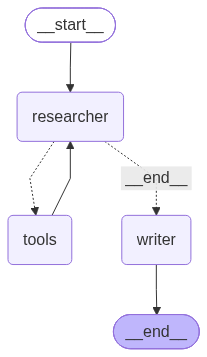

In [10]:
from langgraph.prebuilt import ToolNode, tools_condition

# Build graph
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("tools", ToolNode([search_web, writer_summary]))
workflow.add_node("writer", writer_agent)

# define flow
workflow.set_entry_point("researcher")

# If the researcher's last message contains a tool call, run the "tools" node.
# Otherwise (no tool call pending), go straight to the writer.
workflow.add_conditional_edges(
    "researcher",
    tools_condition,
    {"tools": "tools", END: "writer"},
)

# After running the tool, send the tool result back to the researcher
# so it can read the tool output and produce a final answer.
workflow.add_edge("tools", "researcher")

workflow.add_edge("writer", END)
final_workflow = workflow.compile()

final_workflow

In [11]:
response = final_workflow.invoke({
    "messages": [HumanMessage(content="Research about the use case of agentic AI in business")]
})
response

C:\Users\Mox\AppData\Local\Temp\ipykernel_15488\1163138330.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(max_results=3)


{'messages': [HumanMessage(content='Research about the use case of agentic AI in business', additional_kwargs={}, response_metadata={}, id='17812383-fda4-4ab8-8568-704273256e05'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to research the use case of agentic AI in business. Use search_web.', 'tool_calls': [{'id': 'fc_8714edb3-8254-41cc-b575-cb12c41ec903', 'function': {'arguments': '{"query":"agentic AI use cases in business"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 152, 'total_tokens': 204, 'completion_time': 0.110408145, 'completion_tokens_details': {'reasoning_tokens': 19}, 'prompt_time': 0.007396083, 'prompt_tokens_details': None, 'queue_time': 0.333234253, 'total_time': 0.117804228}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_77b12279f9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_

In [12]:
response["messages"][-1].content

'**Summary of Findings – Agentic AI in Business**\n\n---\n\n### What is Agentic AI?\n- **Beyond generative “copilots.”**  \n  Agentic AI can **plan, decide, and execute multi‑step tasks** across multiple enterprise systems while staying under human oversight.\n- Core abilities: goal‑oriented reasoning, tool integration (APIs, databases, UI), iterative execution with feedback, and built‑in guardrails.\n\n---\n\n### High‑Impact Business Use Cases\n| Function | Example Agentic‑AI Application | Business Value |\n|----------|--------------------------------|----------------|\n| **IT Operations & Incident Management** | Continuous monitoring → automatic root‑cause analysis → remediation before a human notices. | Turns firefighting into proactive reliability; cuts MTTR up to 70\u202f%. |\n| **Customer Service** | AI agent accesses CRM, knowledge base, ticketing system to resolve queries end‑to‑end; escalates only complex cases. | Faster responses, higher satisfaction, frees human agents for h

## supervise Multi Ai Agent Architecture


In [24]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [ ]:
# ===================================
# State Definition
# ===================================

class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = "" # type: ignore
    research_data: str = "" # type: ignore
    analysis: str = "" # type: ignore
    final_report: str = "" # type: ignore
    task_complete: bool = False # type: ignore
    current_task: str = "" # type: ignore

In [26]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [27]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [28]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [29]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [30]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [31]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

In [32]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
    

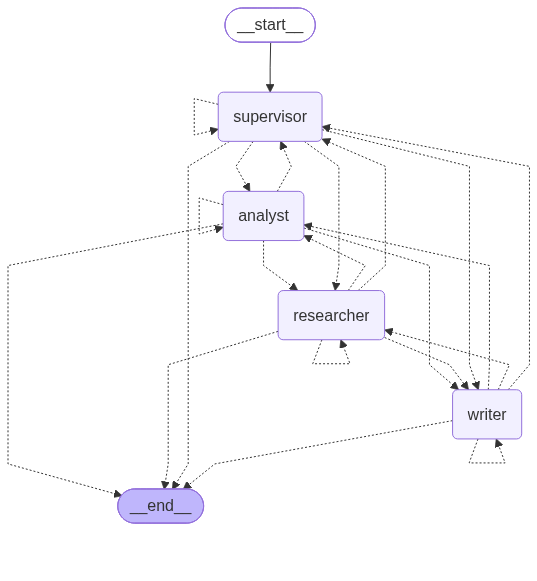

In [33]:

graph

In [37]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

done


In [39]:
response["messages"][-1].content

'✅ Supervisor: All tasks complete! Great work team.'